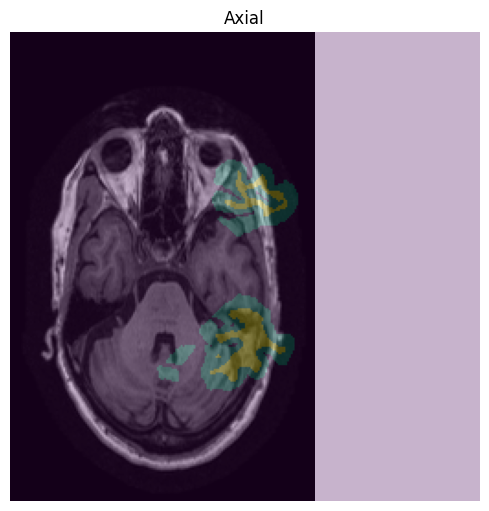

In [8]:
import os
import random
import nibabel as nib
import numpy as np
from matplotlib import pyplot as plt

# --- Paths ---
IMAGE_DIR = "MRIs_SPLIT/val/images"
MASK_DIR = "MRIs_SPLIT/val/masks"

# --- Helper to find corresponding mask ---
def find_mask(image_name, mask_dir):
    stem = os.path.splitext(image_name)[0]  # remove .nii
    for f in os.listdir(mask_dir):
        if f.startswith(stem) and f.endswith("_gm_wm_mask.nii.gz"):
            return os.path.join(mask_dir, f)
    return None

# --- Select random image ---
# all_images = [f for f in os.listdir(IMAGE_DIR) if f.endswith('.nii')]
# image_name = random.choice(all_images)
# image_path = os.path.join(IMAGE_DIR, image_name)

image_path = "MRIs_SPLIT/val/images/ADNI_002_S_0685_MR_MPR-R__GradWarp__B1_Correction__N3_Br_20070217000504186_S16308_I40687.nii"
mask_path = "MRIs_SPLIT/val/masks/ADNI_002_S_0685_MR_MPR-R__GradWarp__B1_Correction__N3_Br_20070217000504186_S16308_I40687_gm_wm_mask.nii.gz"
if mask_path is None:
    raise FileNotFoundError(f"No mask found for {image_name}")

# --- Load images ---
img = nib.load(image_path).get_fdata()
mask_unaligned = nib.load(mask_path).get_fdata()
# Suppose your mask axes are (x, z, y) instead of (x, y, z)
# You can reorder axes to match the image:
mask = np.transpose(mask_unaligned, (1, 0, 2))  # swap 2nd and 3rd axes


# --- Middle slices ---
mid_sagittal = img.shape[2] // 2
mid_axial_img = img.shape[0] // 2
mid_coronal = img.shape[1] // 2

mid_axial_mask = mask.shape[0] // 2


# --- Visualization ---
plt.figure(figsize=(15, 5))

# # Sagittal
# plt.subplot(1, 3, 1)
# plt.title('Sagittal')
# plt.imshow(img[:, :, mid_sagittal], cmap='gray')
# plt.imshow(mask[:, :, mid_sagittal], alpha=0.3, cmap='viridis')
# plt.axis('off')

# Axial
plt.subplot(1, 3, 2)
plt.title('Axial')
plt.imshow(img[mid_axial_img, :, :], cmap='gray')
plt.imshow(mask[mid_axial_mask, :, :], alpha=0.3, cmap='viridis')
plt.axis('off')

# # Coronal
# plt.subplot(1, 3, 3)
# plt.title('Coronal')
# plt.imshow(img[:, mid_coronal, :], cmap='gray')
# plt.imshow(mask[:, mid_coronal, :], alpha=0.3, cmap='viridis')
# plt.axis('off')

plt.tight_layout()
plt.show()


/tmp/ipykernel_812017/2538433560.py:19: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  mask_resampled_nii = resample_img(
/tmp/ipykernel_812017/2538433560.py:19: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  mask_resampled_nii = resample_img(


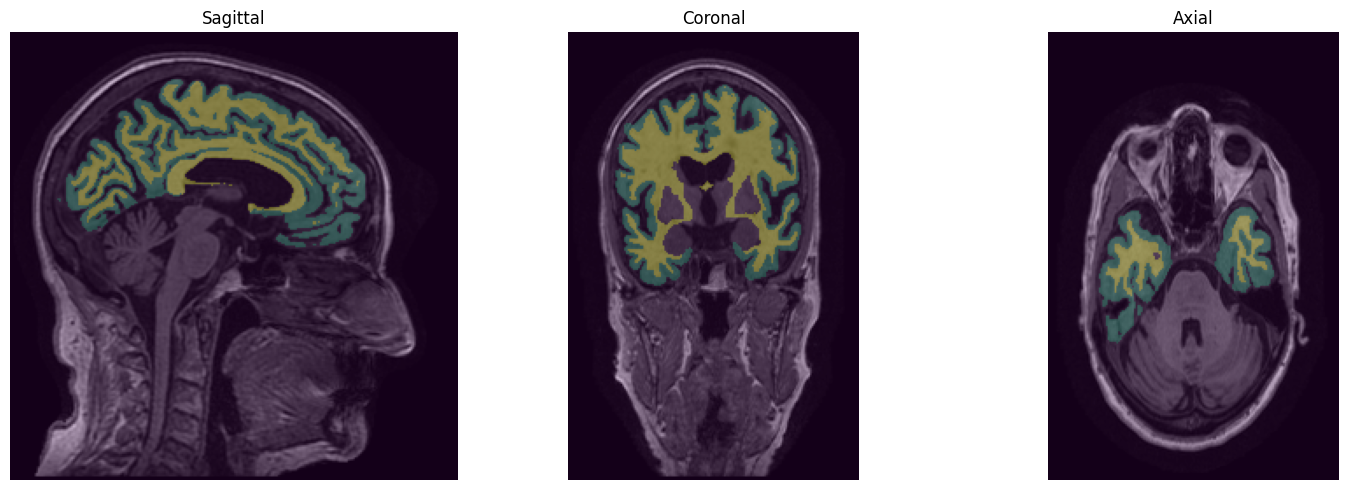

In [ ]:
import os
import nibabel as nib
from nilearn.image import resample_img
import numpy as np
from nibabel.orientations import io_orientation, axcodes2ornt, ornt_transform, apply_orientation
from matplotlib import pyplot as plt
from skimage.transform import resize

# --- Paths ---
image_path = "MRIs_SPLIT/val/images/ADNI_002_S_0685_MR_MPR-R__GradWarp__B1_Correction__N3_Br_20070217000504186_S16308_I40687.nii"
mask_path = "MRIs_SPLIT/val/masks/ADNI_002_S_0685_MR_MPR-R__GradWarp__B1_Correction__N3_Br_20070217000504186_S16308_I40687_gm_wm_mask.nii.gz"

# --- Load images ---
# Load NIfTI
img_nii = nib.load(image_path)
mask_nii = nib.load(mask_path)

# Resample mask to match image
mask_resampled_nii = resample_img(
    mask_nii, 
    target_affine=img_nii.affine, 
    target_shape=img_nii.shape,
    interpolation='nearest'  # keep it binary
)
# --- Reorient both image and resampled mask to RAS ---
def reorient_to_ras(data, affine):
    current_ornt = io_orientation(affine)
    ras_ornt = axcodes2ornt(('R','A','S'))
    transform = ornt_transform(current_ornt, ras_ornt)
    return apply_orientation(data, transform)

img_ras = reorient_to_ras(img_nii.get_fdata(), img_nii.affine)
mask_ras = reorient_to_ras(mask_resampled_nii.get_fdata(), mask_resampled_nii.affine)

# --- Resize mask to match image (if needed) ---
if img_ras.shape != mask_ras.shape:
    mask_ras = resize(mask_ras, img_ras.shape, order=0, preserve_range=True, anti_aliasing=False)

# --- Middle slices ---
mid_sagittal = img_ras.shape[0] // 2
mid_coronal = img_ras.shape[1] // 2
mid_axial = img_ras.shape[2] // 2

# --- Visualization ---
plt.figure(figsize=(15, 5))

# Sagittal
plt.subplot(1, 3, 1)
plt.title('Sagittal')
plt.imshow(img_ras[mid_sagittal, :, :].T, cmap='gray', origin='lower')
plt.imshow(mask_ras[mid_sagittal, :, :].T, alpha=0.3, cmap='viridis', origin='lower')
plt.axis('off')

# Coronal
plt.subplot(1, 3, 2)
plt.title('Coronal')
plt.imshow(img_ras[:, mid_coronal, :].T, cmap='gray', origin='lower')
plt.imshow(mask_ras[:, mid_coronal, :].T, alpha=0.3, cmap='viridis', origin='lower')
plt.axis('off')

# Axial
plt.subplot(1, 3, 3)
plt.title('Axial')
plt.imshow(img_ras[:, :, mid_axial].T, cmap='gray', origin='lower')
plt.imshow(mask_ras[:, :, mid_axial].T, alpha=0.3, cmap='viridis', origin='lower')
plt.axis('off')

plt.tight_layout()
plt.show()
